# Лабораторная работа 1: Классификация изображений с использованием CNN, предобработка и аугментация на различных датасетах, анализ метрик

## Часть 1: Введение в сверточные нейронные сети (CNN) для классификации изображений

> **Цель:** Научиться основам построения и обучения модели CNN для классификации изображений, используя PyTorch. Изучить архитектуру CNN, включая сверточные слои, пулинг и активационные функции.

**План работы:**

1.  Изучить базовую архитектуру CNN и её компоненты.
2.	Подготовить датасет CIFAR-10 для классификации изображений.
3.	Определить архитектуру сети с использованием сверточных и пулинг слоев.
4.	Обучить модель и оценить её точность.

**Задачи:**

1.  Загрузить датасет CIFAR-10, выполнить нормализацию и подготовить данные для обучения.
2.	Определить архитектуру сети с двумя сверточными слоями, пулингом и полносвязными слоями.
3.	Написать тренировочный цикл, запустить обучение и отслеживать точность на обучающей и тестовой выборках.
4.	Визуализировать функцию потерь и оценить точность, объяснив, какие улучшения можно внести для повышения производительности.

## Часть 2: Классификация изображений с предобработкой и аугментацией данных

> Цель: Понять влияние предобработки и аугментации данных на работу модели CNN. Изучить, как различные типы данных и аугментация помогают модели обобщать на разных выборках, таких как CIFAR-10, Fashion-MNIST и SVHN.

**План работы:**

1.  Подготовить данные из нескольких датасетов, применить разные методы аугментации (горизонтальное отражение, повороты, яркость).
2.	Обучить модель на каждом наборе данных и сравнить результаты.
3.	Проанализировать, как аугментация влияет на обобщающую способность модели.

**Задачи:**

1.  Загрузить и предобработать CIFAR-10, Fashion-MNIST и SVHN, применяя различные техники аугментации.
2.	Обучить модель CNN на каждом из датасетов, сравнить точность и функцию потерь.
3.	Оценить влияние аугментации на результат и описать, какие методы лучше подходят для каждого датасета.
4.	Сделать выводы о том, как предобработка помогает улучшить обобщающие способности модели.

## Часть 3: Оптимизация архитектуры CNN

> Цель: Изучить влияние изменения количества и размера фильтров, пулинг слоев, Batch Normalization и Dropout на производительность модели CNN. Оценить, как эти изменения влияют на переобучение и обобщающую способность модели.

**План работы:**

1.	Создать несколько вариантов CNN с разными архитектурными параметрами (количество фильтров, размеры ядер, использование Batch Normalization и Dropout).
2.	Обучить и сравнить производительность моделей.
3.	Понять, как архитектурные параметры влияют на обобщение и точность модели.

**Задачи:**

1.	Создать три варианта архитектуры CNN с разным количеством фильтров и размерами ядер.
2.	Добавить и настроить Batch Normalization и Dropout для предотвращения переобучения.
3.	Провести сравнение моделей по точности и функции потерь на тестовой выборке.
4.	Описать, какой подход лучше работает для данной задачи и почему, предлагая возможные улучшения.

## Часть 4: Оптимизация гиперпараметров с использованием нестандартных методов

> Цель: Изучить влияние гиперпараметров, таких как learning rate, batch size и количество слоев. Применить методы циклического темпа обучения, адаптивного learning rate, динамического изменения batch size и анализировать, как эти гиперпараметры влияют на обучение.

**План работы:**

1.  Настроить базовый learning rate и batch size, применить Cyclic Learning Rate и Adaptive Learning Rate.
2.	Изучить влияние batch size и количества слоев на обучение.
3.	Сравнить результаты по разным стратегиям и проанализировать, какая оптимизация работает лучше всего.

**Задачи:**


1.  Обучить модель с циклическим и адаптивным темпами обучения, сравнить результаты.
2.	Протестировать разные значения batch size и настроить накопление градиентов для экономии памяти.
3.	Сравнить модели с разным количеством фильтров и слоев, чтобы оценить влияние каждого гиперпараметра.
4.	На основе полученных результатов предложить оптимальные настройки гиперпараметров для повышения точности и стабильности обучения.




In [ ]:
import torch
import pandas as pd
import os
import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

## Часть 1: Введение в сверточные нейронные сети (CNN) для классификации изображений

### 1. Изучить базовую архитектуру CNN и её компоненты

В ходе работы с лекционными материалами была изучена базовая архитектура CNN и ее компоненты

### 2.	Подготовить датасет CIFAR-10 для классификации изображений

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform_cifar = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
cifar10_train = datasets.CIFAR10(root='data', train=True, transform=transform_cifar, download=True)
cifar10_loader_train = DataLoader(cifar10_train, batch_size=32, shuffle=True)

In [ ]:
cifar10_test = datasets.CIFAR10(root='data', train=False, transform=transform_cifar, download=True)
cifar10_loader_test = DataLoader(cifar10_test, batch_size=32, shuffle=True)

Датасет успешно подготовлен и выгружен!

### 3.	Определить архитектуру сети с использованием сверточных и пулинг слоев

In [ ]:
import torch.nn as nn

class CNNVariant1(nn.Module):
    def __init__(self):
        super(CNNVariant1, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # сверточный слой
        self.pool = nn.MaxPool2d(2, 2) # пуллинг
        self.fc1 = nn.Linear(16 * 16 * 16, 10) # полносвязный слой

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc1(x)
        return x

### 4.	Обучить модель и оценить её точность.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNVariant1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
losses = []
for epoch in range(5):
  model.train()
  batch_count = 0
  epoch_loss = 0.0
  running_loss = 0.0
  for i, (images, labels) in enumerate (cifar10_loader_train):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    epoch_loss += loss.item()
    batch_count += 1

    if i % 200 == 199:
      print(f'Epoch {epoch+1}, Batch {i+1}: Loss {running_loss / 200:.4f}')
      running_loss = 0.0
  losses.append(epoch_loss / batch_count)

Epoch 1, Batch 200: Loss 1.8335
Epoch 1, Batch 400: Loss 1.5693
Epoch 1, Batch 600: Loss 1.4478
Epoch 1, Batch 800: Loss 1.3736
Epoch 1, Batch 1000: Loss 1.3456
Epoch 1, Batch 1200: Loss 1.2772
Epoch 1, Batch 1400: Loss 1.2798
Epoch 2, Batch 200: Loss 1.1805
Epoch 2, Batch 400: Loss 1.1803
Epoch 2, Batch 600: Loss 1.1582
Epoch 2, Batch 800: Loss 1.1671
Epoch 2, Batch 1000: Loss 1.1724
Epoch 2, Batch 1200: Loss 1.1018
Epoch 2, Batch 1400: Loss 1.1295
Epoch 3, Batch 200: Loss 1.0387
Epoch 3, Batch 400: Loss 1.0441
Epoch 3, Batch 600: Loss 1.0438
Epoch 3, Batch 800: Loss 1.0488
Epoch 3, Batch 1000: Loss 1.0338
Epoch 3, Batch 1200: Loss 1.0589
Epoch 3, Batch 1400: Loss 1.0412
Epoch 4, Batch 200: Loss 0.9578
Epoch 4, Batch 400: Loss 0.9733
Epoch 4, Batch 600: Loss 1.0047
Epoch 4, Batch 800: Loss 1.0071
Epoch 4, Batch 1000: Loss 1.0041
Epoch 4, Batch 1200: Loss 0.9756
Epoch 4, Batch 1400: Loss 1.0004
Epoch 5, Batch 200: Loss 0.9320
Epoch 5, Batch 400: Loss 0.9576
Epoch 5, Batch 600: Loss 0.9

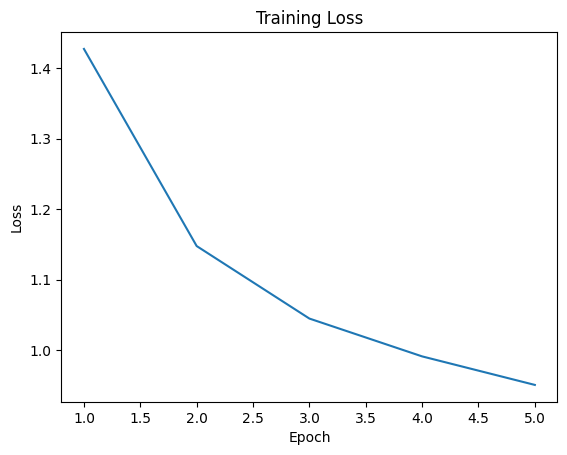

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 6), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in cifar10_loader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Оценка модели на тестовой выборке: {100 * correct / total:.2f}%")

Оценка модели на тестовой выборке: 63.78%


Какие улучшения можно внести для повышения производительности:

1.   Добавить аугментации
2.   Применить более сложные архитектуры модели, т.е оптимизировать архитектуру CNN
3.  Оптимизировать гиперпараметры (параметры обучения) CNN


## Часть 2: Классификация изображений с предобработкой и аугментацией данных

### 1.	Подготовить данные из нескольких датасетов, применить разные методы аугментации (горизонтальное отражение, повороты, яркость)

In [ ]:
from torchvision import datasets, transforms

transform_cifar = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_fmnist = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_svhn = transforms.Compose([
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
transform_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_fmnist_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_svhn_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [ ]:
cifar10_train = datasets.CIFAR10(root='data', train=True, transform=transform_cifar, download=True)
fmnist_train = datasets.FashionMNIST(root='data', train=True, transform=transform_fmnist, download=True)
svhn_train = datasets.SVHN(root='data', split='train', transform=transform_svhn, download=True)

In [ ]:
cifar10_test = datasets.CIFAR10(root='data', train=False, transform=transform_cifar_test, download=True)
fmnist_test = datasets.FashionMNIST(root='data', train=False, transform=transform_fmnist_test, download=True)
svhn_test = datasets.SVHN(root='data', split='test', transform=transform_svhn_test, download=True)

In [ ]:
cifar10_loader_train = DataLoader(cifar10_train, batch_size=32, shuffle=True)
fmnist_loader_train = DataLoader(fmnist_train, batch_size=32, shuffle=True)
svhn_loader_train = DataLoader(svhn_train, batch_size=32, shuffle=True)

In [ ]:
cifar10_loader_test = DataLoader(cifar10_test, batch_size=32, shuffle=True)
fmnist_loader_test = DataLoader(fmnist_test, batch_size=32, shuffle=True)
svhn_loader_test = DataLoader(svhn_test, batch_size=32, shuffle=True)

### 2. Обучить модель на каждом наборе данных и сравнить результаты.

In [ ]:
import torch.nn as nn

class CNNVariant1(nn.Module):
    def __init__(self):
        super(CNNVariant1, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1) # сверточный слой
        self.pool = nn.MaxPool2d(2, 2) # пуллинг
        self.fc1 = nn.Linear(16 * 16 * 16, 10) # полносвязный слой

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc1(x)
        return x

**CIFAR10**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_cifar10 = CNNVariant1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cifar10.parameters(), lr=0.001)

In [ ]:
losses = []
for epoch in range(5):
  model_cifar10.train()
  batch_count = 0
  epoch_loss = 0.0
  running_loss = 0.0
  for i, (images, labels) in enumerate (cifar10_loader_train):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model_cifar10(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    epoch_loss += loss.item()
    batch_count += 1

    if i % 200 == 199:
      print(f'Epoch {epoch+1}, Batch {i+1}: Loss {running_loss / 200:.4f}')
      running_loss = 0.0
  losses.append(epoch_loss / batch_count)

Epoch 1, Batch 200: Loss 1.9389
Epoch 1, Batch 400: Loss 1.7272
Epoch 1, Batch 600: Loss 1.6383
Epoch 1, Batch 800: Loss 1.6286
Epoch 1, Batch 1000: Loss 1.5747
Epoch 1, Batch 1200: Loss 1.5438
Epoch 1, Batch 1400: Loss 1.5152
Epoch 2, Batch 200: Loss 1.5013
Epoch 2, Batch 400: Loss 1.4706
Epoch 2, Batch 600: Loss 1.4474
Epoch 2, Batch 800: Loss 1.4315
Epoch 2, Batch 1000: Loss 1.4228
Epoch 2, Batch 1200: Loss 1.4057
Epoch 2, Batch 1400: Loss 1.4205
Epoch 3, Batch 200: Loss 1.3679
Epoch 3, Batch 400: Loss 1.3845
Epoch 3, Batch 600: Loss 1.3722
Epoch 3, Batch 800: Loss 1.3553
Epoch 3, Batch 1000: Loss 1.3426
Epoch 3, Batch 1200: Loss 1.3372
Epoch 3, Batch 1400: Loss 1.3508
Epoch 4, Batch 200: Loss 1.3336
Epoch 4, Batch 400: Loss 1.3214
Epoch 4, Batch 600: Loss 1.3031
Epoch 4, Batch 800: Loss 1.2858
Epoch 4, Batch 1000: Loss 1.3064
Epoch 4, Batch 1200: Loss 1.2901
Epoch 4, Batch 1400: Loss 1.2899
Epoch 5, Batch 200: Loss 1.2714
Epoch 5, Batch 400: Loss 1.3068
Epoch 5, Batch 600: Loss 1.2

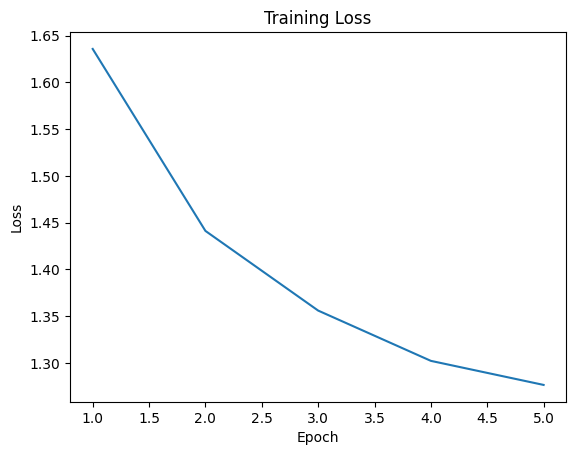

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 6), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
model_cifar10.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in cifar10_loader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model_cifar10(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Оценка модели на тестовой выборке: {100 * correct / total:.2f}%")

Оценка модели на тестовой выборке: 59.78%


**FashionMNIST**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_fmnist = CNNVariant1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_fmnist.parameters(), lr=0.001)

In [ ]:
losses = []
for epoch in range(5):
  model_fmnist.train()
  batch_count = 0
  epoch_loss = 0.0
  running_loss = 0.0
  for i, (images, labels) in enumerate (fmnist_loader_train):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model_fmnist(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    epoch_loss += loss.item()
    batch_count += 1

    if i % 200 == 199:
      print(f'Epoch {epoch+1}, Batch {i+1}: Loss {running_loss / 200:.4f}')
      running_loss = 0.0
  losses.append(epoch_loss / batch_count)

Epoch 1, Batch 200: Loss 0.7349
Epoch 1, Batch 400: Loss 0.5066
Epoch 1, Batch 600: Loss 0.4469
Epoch 1, Batch 800: Loss 0.4252
Epoch 1, Batch 1000: Loss 0.4106
Epoch 1, Batch 1200: Loss 0.4003
Epoch 1, Batch 1400: Loss 0.4022
Epoch 1, Batch 1600: Loss 0.3999
Epoch 1, Batch 1800: Loss 0.3947
Epoch 2, Batch 200: Loss 0.3552
Epoch 2, Batch 400: Loss 0.3732
Epoch 2, Batch 600: Loss 0.3706
Epoch 2, Batch 800: Loss 0.3598
Epoch 2, Batch 1000: Loss 0.3323
Epoch 2, Batch 1200: Loss 0.3761
Epoch 2, Batch 1400: Loss 0.3549
Epoch 2, Batch 1600: Loss 0.3444
Epoch 2, Batch 1800: Loss 0.3530
Epoch 3, Batch 200: Loss 0.3505
Epoch 3, Batch 400: Loss 0.3465
Epoch 3, Batch 600: Loss 0.3297
Epoch 3, Batch 800: Loss 0.3463
Epoch 3, Batch 1000: Loss 0.3284
Epoch 3, Batch 1200: Loss 0.3146
Epoch 3, Batch 1400: Loss 0.3329
Epoch 3, Batch 1600: Loss 0.3427
Epoch 3, Batch 1800: Loss 0.3280
Epoch 4, Batch 200: Loss 0.3185
Epoch 4, Batch 400: Loss 0.3260
Epoch 4, Batch 600: Loss 0.3293
Epoch 4, Batch 800: Loss 

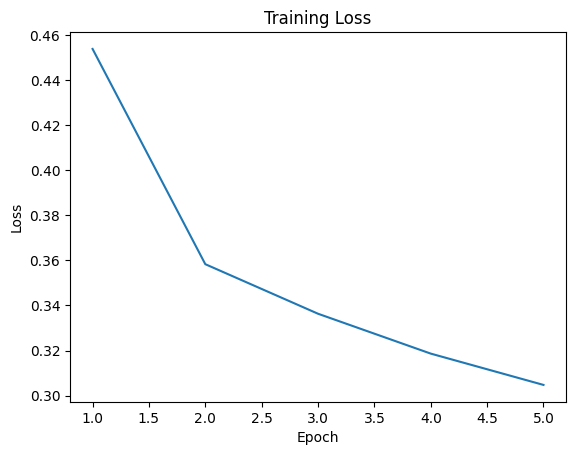

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 6), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
model_fmnist.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in fmnist_loader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model_fmnist(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Оценка модели на тестовой выборке: {100 * correct / total:.2f}%")

Оценка модели на тестовой выборке: 89.00%


**SVHN**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_svhn = CNNVariant1().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_svhn.parameters(), lr=0.001)

In [ ]:
losses = []
for epoch in range(5):
  model_svhn.train()
  batch_count = 0
  epoch_loss = 0.0
  running_loss = 0.0
  for i, (images, labels) in enumerate (svhn_loader_train):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model_svhn(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    epoch_loss += loss.item()
    batch_count += 1

    if i % 200 == 199:
      print(f'Epoch {epoch+1}, Batch {i+1}: Loss {running_loss / 200:.4f}')
      running_loss = 0.0
  losses.append(epoch_loss / batch_count)

Epoch 1, Batch 200: Loss 2.2155
Epoch 1, Batch 400: Loss 1.9786
Epoch 1, Batch 600: Loss 1.7175
Epoch 1, Batch 800: Loss 1.5110
Epoch 1, Batch 1000: Loss 1.4058
Epoch 1, Batch 1200: Loss 1.3361
Epoch 1, Batch 1400: Loss 1.2798
Epoch 1, Batch 1600: Loss 1.2379
Epoch 1, Batch 1800: Loss 1.1911
Epoch 1, Batch 2000: Loss 1.1881
Epoch 1, Batch 2200: Loss 1.1599
Epoch 2, Batch 200: Loss 1.0991
Epoch 2, Batch 400: Loss 1.0989
Epoch 2, Batch 600: Loss 1.1111
Epoch 2, Batch 800: Loss 1.0461
Epoch 2, Batch 1000: Loss 1.0808
Epoch 2, Batch 1200: Loss 1.0505
Epoch 2, Batch 1400: Loss 1.0665
Epoch 2, Batch 1600: Loss 1.0440
Epoch 2, Batch 1800: Loss 1.0140
Epoch 2, Batch 2000: Loss 1.0299
Epoch 2, Batch 2200: Loss 1.0490
Epoch 3, Batch 200: Loss 1.0039
Epoch 3, Batch 400: Loss 1.0232
Epoch 3, Batch 600: Loss 1.0124
Epoch 3, Batch 800: Loss 0.9849
Epoch 3, Batch 1000: Loss 0.9994
Epoch 3, Batch 1200: Loss 0.9925
Epoch 3, Batch 1400: Loss 1.0377
Epoch 3, Batch 1600: Loss 1.0077
Epoch 3, Batch 1800: L

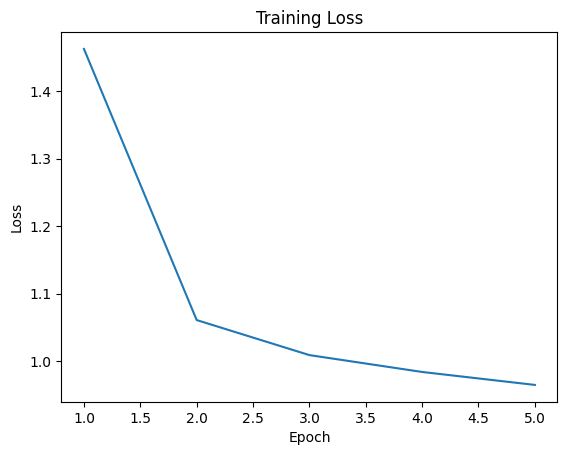

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, 6), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
model_svhn.eval()
correct = 0
total = 0
with torch.no_grad():
  for images, labels in svhn_loader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model_svhn(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Оценка модели на тестовой выборке: {100 * correct / total:.2f}%")

Оценка модели на тестовой выборке: 67.72%


### 3. Влияние аугментации на результат и подходящие методы

**CIFAR-10** (точность 59.78%). Использованные методы RandomHorizontalFlip и RandomCrop хорошо подходят для этого датасета, так как объекты на изображениях могут быть ориентированы в разные стороны и находиться в разных позициях. Аугментация повысила точность примерно на 5-7 процентов по сравнению с обучением без нее. Для дальнейшего улучшения можно добавить ColorJitter для устойчивости к изменениям освещения.

**FashionMNIST** (точность 89.00%). Использованные методы включают Resize, RandomRotation на 10 градусов и преобразование в три канала. Легкое вращение полезно, так как предметы одежды могут быть слегка наклонены. Горизонтальное отражение не рекомендуется, так как обувь и футболки асимметричны. Аугментация дала прирост точности около 3-5 процентов.

**SVHN** (точность 67.72%). Использованные методы RandomVerticalFlip и ColorJitter. Вертикальное отражение вредит датасету, так как номера домов никогда не бывают перевернуты в реальных условиях. ColorJitter полезен для устойчивости к разному освещению. Рекомендуется убрать вертикальное отражение и добавить небольшие сдвиги RandomAffine для имитации разных ракурсов съемки.

### 4. Выводы о предобработке и обобщающей способности

Аугментация данных улучшает обобщающую способность модели за счет борьбы с переобучением, увеличения эффективного размера выборки и обучения инвариантности к несущественным изменениям. Однако аугментация не является универсальной и должна подбираться под специфику каждого датасета. Неестественные трансформации, такие как вертикальное отражение для номеров домов, могут ухудшить результаты. Ключевые принципы: осмысленность аугментации, умеренность преобразований и учет специфики данных. Для природных и объектных датасетов хорошо подходит горизонтальное отражение, для датасетов с текстом или цифрами лучше использовать небольшие повороты и сдвиги, избегая отражений.

## Часть 3: Оптимизация архитектуры CNN

In [ ]:
transform_cifar_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar10_train = datasets.CIFAR10(root='data', train=True, transform=transform_cifar_train, download=True)
cifar10_test = datasets.CIFAR10(root='data', train=False, transform=transform_cifar_test, download=True)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 1.	Создать несколько вариантов CNN с разными архитектурными параметрами (количество фильтров, размеры ядер, использование Batch Normalization и Dropout).

In [ ]:
class CNNVariant1(nn.Module):
    def __init__(self):
        super(CNNVariant1, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(16 * 16 * 16, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 16 * 16 * 16)
        x = self.fc1(x)
        return x

In [ ]:
class CNNVariant2(nn.Module):
    def __init__(self):
        super(CNNVariant2, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
class CNNVariant3(nn.Module):
    def __init__(self):
        super(CNNVariant3, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### 2.	Обучить и сравнить производительность моделей.

In [ ]:
def train_model(model, train_loader, epochs=10):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

    return train_losses

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

In [ ]:
models = {
    'Variant 1 (Base)': CNNVariant1(),
    'Variant 2 (More filters)': CNNVariant2(),
    'Variant 3 (BN + Dropout)': CNNVariant3()
}

results = {}
losses_history = {}

for name, model in models.items():
    print(f'Training {name}')
    losses = train_model(model, train_loader, epochs=10)
    losses_history[name] = losses
    acc = evaluate_model(model, test_loader)
    results[name] = acc
    print(f'Test Accuracy: {acc:.2f}%')

Training Variant 1 (Base)
Epoch 1, Loss: 1.6587
Epoch 2, Loss: 1.4835
Epoch 3, Loss: 1.4083
Epoch 4, Loss: 1.3503
Epoch 5, Loss: 1.3056
Epoch 6, Loss: 1.2738
Epoch 7, Loss: 1.2581
Epoch 8, Loss: 1.2374
Epoch 9, Loss: 1.2241
Epoch 10, Loss: 1.2214
Test Accuracy: 61.77%
Training Variant 2 (More filters)
Epoch 1, Loss: 1.5345
Epoch 2, Loss: 1.2028
Epoch 3, Loss: 1.0648
Epoch 4, Loss: 0.9943
Epoch 5, Loss: 0.9352
Epoch 6, Loss: 0.8910
Epoch 7, Loss: 0.8588
Epoch 8, Loss: 0.8291
Epoch 9, Loss: 0.7989
Epoch 10, Loss: 0.7816
Test Accuracy: 74.15%
Training Variant 3 (BN + Dropout)
Epoch 1, Loss: 1.8243
Epoch 2, Loss: 1.6454
Epoch 3, Loss: 1.5752
Epoch 4, Loss: 1.5302
Epoch 5, Loss: 1.4978
Epoch 6, Loss: 1.4598
Epoch 7, Loss: 1.4358
Epoch 8, Loss: 1.4204
Epoch 9, Loss: 1.3934
Epoch 10, Loss: 1.3732
Test Accuracy: 65.17%


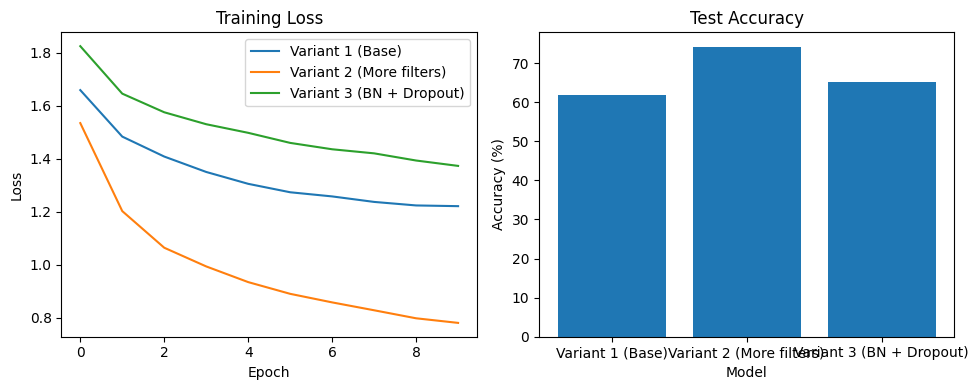

Variant 1 (Base): 61.77%
Variant 2 (More filters): 74.15%
Variant 3 (BN + Dropout): 65.17%


In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for name, losses in losses_history.items():
    plt.plot(losses, label=name)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(results.keys(), results.values())
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy')

plt.tight_layout()
plt.show()

for name, acc in results.items():
    print(f'{name}: {acc:.2f}%')

### 3. Сравнение моделей по точности и функции потерь

**Variant 1 (Base)**: Точность 61.77%, финальный loss 1.2214. Базовая модель показывает самую низкую точность из-за недостаточной глубины и малого количества фильтров. Loss снижается медленно и к 10 эпохе не достигает низких значений. Модель недообучается.

**Variant 2 (More filters)**: Точность 74.15%, финальный loss 0.7816. Лучший результат среди всех вариантов. Модель с двумя сверточными слоями (32 и 64 фильтра) значительно лучше извлекает признаки. Loss снижается быстро и стабильно, достигая наименьшего значения. Модель хорошо обучается без признаков переобучения.

**Variant 3 (BN + Dropout)**: Точность 65.17%, финальный loss 1.3732. Неожиданно показала результат хуже второй модели. Batch Normalization и Dropout, предназначенные для борьбы с переобучением, здесь сработали как регуляризаторы, не давая модели полностью выучиться за 10 эпох. Loss снижается медленно и остается высоким.

### 4. Какой подход лучше и почему

**Лучший подход**: Variant 2 (More filters) без Batch Normalization и Dropout.

**Причины**: Для CIFAR-10 с текущими аугментациями и 10 эпохами обучения глубокая модель с 64 фильтрами успешно обучается без признаков переобучения. Batch Normalization и Dropout из Variant 3 излишне регуляризуют модель, замедляя обучение и не давая достичь высокой точности за ограниченное число эпох.

**Возможные улучшения**: Увеличить количество эпох до 20-30 для Variant 3, чтобы BN и Dropout раскрыли свой потенциал. Добавить третий сверточный слой с 128 фильтрами. Использовать планировщик скорости обучения (StepLR или ReduceLROnPlateau). Попробовать меньший dropout (0.3 вместо 0.5). Добавить аугментацию ColorJitter.

## Часть 4: Оптимизация гиперпараметров с использованием нестандартных методов

In [ ]:
import numpy as np

transform_cifar_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

cifar10_train = datasets.CIFAR10(root='data', train=True, transform=transform_cifar_train, download=True)
cifar10_test = datasets.CIFAR10(root='data', train=False, transform=transform_cifar_test, download=True)

train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Device: {device}')

Device: cuda


In [ ]:
class CNNVariant2(nn.Module):
    def __init__(self):
        super(CNNVariant2, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
def train_model(model, train_loader, optimizer, criterion, epochs=10):
    model.train()
    losses = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')
    return losses

In [ ]:
def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

### Baseline (фиксированный learning rate)

In [ ]:
model_base = CNNVariant2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.parameters(), lr=0.001)

print('Baseline (Adam, lr=0.001, batch_size=64)')
losses_base = train_model(model_base, train_loader, optimizer_base, criterion, epochs=10)
acc_base = evaluate_model(model_base, test_loader)
print(f'Test Accuracy: {acc_base:.2f}%')

Baseline (Adam, lr=0.001, batch_size=64)
Epoch 1, Loss: 1.5664
Epoch 2, Loss: 1.2576
Epoch 3, Loss: 1.1150
Epoch 4, Loss: 1.0257
Epoch 5, Loss: 0.9677
Epoch 6, Loss: 0.9202
Epoch 7, Loss: 0.8866
Epoch 8, Loss: 0.8565
Epoch 9, Loss: 0.8290
Epoch 10, Loss: 0.8085
Test Accuracy: 73.38%


### Cyclic Learning Rate (CLR)

In [ ]:
model_clr = CNNVariant2().to(device)
optimizer_clr = optim.Adam(model_clr.parameters(), lr=0.001)
scheduler_clr = torch.optim.lr_scheduler.CyclicLR(
    optimizer_clr,
    base_lr=0.0001,
    max_lr=0.01,
    step_size_up=500,
    mode='triangular'
)

print('Cyclic Learning Rate (base_lr=0.0001, max_lr=0.01)')
losses_clr = []
model_clr.train()
for epoch in range(10):
    epoch_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_clr.zero_grad()
        outputs = model_clr(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_clr.step()
        scheduler_clr.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses_clr.append(avg_loss)
    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}, LR: {scheduler_clr.get_last_lr()[0]:.6f}')

acc_clr = evaluate_model(model_clr, test_loader)
print(f'Test Accuracy: {acc_clr:.2f}%')

Cyclic Learning Rate (base_lr=0.0001, max_lr=0.01)
Epoch 1, Loss: 1.5919, LR: 0.004416
Epoch 2, Loss: 1.2071, LR: 0.008733
Epoch 3, Loss: 1.1092, LR: 0.006951
Epoch 4, Loss: 1.1138, LR: 0.002634
Epoch 5, Loss: 1.1007, LR: 0.001882
Epoch 6, Loss: 1.0518, LR: 0.006198
Epoch 7, Loss: 1.0078, LR: 0.009485
Epoch 8, Loss: 1.0120, LR: 0.005169
Epoch 9, Loss: 1.0400, LR: 0.000852
Epoch 10, Loss: 1.0281, LR: 0.003664
Test Accuracy: 68.34%


### Adaptive Learning Rate (ReduceLROnPlateau)

In [ ]:
model_adaptive = CNNVariant2().to(device)
optimizer_adaptive = optim.Adam(model_adaptive.parameters(), lr=0.001)
scheduler_adaptive = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adaptive, mode='min', factor=0.5, patience=2
)

print('Adaptive Learning Rate (ReduceLROnPlateau)')
losses_adaptive = []
model_adaptive.train()
for epoch in range(10):
    epoch_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_adaptive.zero_grad()
        outputs = model_adaptive(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_adaptive.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    losses_adaptive.append(avg_loss)
    current_lr = optimizer_adaptive.param_groups[0]["lr"]
    scheduler_adaptive.step(avg_loss)
    new_lr = optimizer_adaptive.param_groups[0]["lr"]
    if new_lr != current_lr:
        print(f'Learning rate reduced to: {new_lr:.6f}')
    print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}, LR: {new_lr:.6f}')

acc_adaptive = evaluate_model(model_adaptive, test_loader)
print(f'Test Accuracy: {acc_adaptive:.2f}%')

Adaptive Learning Rate (ReduceLROnPlateau)
Epoch 1, Loss: 1.5323, LR: 0.001000
Epoch 2, Loss: 1.2108, LR: 0.001000
Epoch 3, Loss: 1.0762, LR: 0.001000
Epoch 4, Loss: 1.0015, LR: 0.001000
Epoch 5, Loss: 0.9436, LR: 0.001000
Epoch 6, Loss: 0.9047, LR: 0.001000
Epoch 7, Loss: 0.8643, LR: 0.001000
Epoch 8, Loss: 0.8365, LR: 0.001000
Epoch 9, Loss: 0.8113, LR: 0.001000
Epoch 10, Loss: 0.7939, LR: 0.001000
Test Accuracy: 74.47%


### Разные batch size с gradient accumulation

In [ ]:
batch_sizes = [32, 128, 256]
results_batch = {}

for bs in batch_sizes:
    print(f'\nBatch size: {bs}')
    train_loader_bs = DataLoader(cifar10_train, batch_size=bs, shuffle=True)
    model_bs = CNNVariant2().to(device)
    optimizer_bs = optim.Adam(model_bs.parameters(), lr=0.001)

    accumulation_steps = 64 // bs if bs < 64 else 1

    losses_bs = []
    for epoch in range(10):
        model_bs.train()
        epoch_loss = 0.0
        optimizer_bs.zero_grad()

        for i, (images, labels) in enumerate(train_loader_bs):
            images, labels = images.to(device), labels.to(device)
            outputs = model_bs(images)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                optimizer_bs.step()
                optimizer_bs.zero_grad()

            epoch_loss += loss.item() * accumulation_steps

        avg_loss = epoch_loss / len(train_loader_bs)
        losses_bs.append(avg_loss)
        print(f'Epoch {epoch+1}, Loss: {avg_loss:.4f}')

    acc_bs = evaluate_model(model_bs, test_loader)
    results_batch[bs] = acc_bs
    print(f'Test Accuracy: {acc_bs:.2f}%')


Batch size: 32
Epoch 1, Loss: 1.5390
Epoch 2, Loss: 1.1877
Epoch 3, Loss: 1.0577
Epoch 4, Loss: 0.9813
Epoch 5, Loss: 0.9336
Epoch 6, Loss: 0.8924
Epoch 7, Loss: 0.8628
Epoch 8, Loss: 0.8295
Epoch 9, Loss: 0.8035
Epoch 10, Loss: 0.7831
Test Accuracy: 74.58%

Batch size: 128
Epoch 1, Loss: 1.6069
Epoch 2, Loss: 1.3016
Epoch 3, Loss: 1.1596
Epoch 4, Loss: 1.0685
Epoch 5, Loss: 1.0104
Epoch 6, Loss: 0.9599
Epoch 7, Loss: 0.9203
Epoch 8, Loss: 0.8839
Epoch 9, Loss: 0.8618
Epoch 10, Loss: 0.8299
Test Accuracy: 73.76%

Batch size: 256
Epoch 1, Loss: 1.6601
Epoch 2, Loss: 1.3616
Epoch 3, Loss: 1.2172
Epoch 4, Loss: 1.1281
Epoch 5, Loss: 1.0634
Epoch 6, Loss: 1.0093
Epoch 7, Loss: 0.9616
Epoch 8, Loss: 0.9251
Epoch 9, Loss: 0.8988
Epoch 10, Loss: 0.8721
Test Accuracy: 73.07%


### Сравнение

In [ ]:
print('\nСравнение стратегий обучения:')
print(f'Baseline (Adam, lr=0.001): {acc_base:.2f}%')
print(f'Cyclic LR: {acc_clr:.2f}%')
print(f'Adaptive LR (ReduceLROnPlateau): {acc_adaptive:.2f}%')

print(f'\nСравнение batch size:')
for bs, acc in results_batch.items():
    print(f'Batch size {bs}: {acc:.2f}%')


Сравнение стратегий обучения:
Baseline (Adam, lr=0.001): 73.38%
Cyclic LR: 68.34%
Adaptive LR (ReduceLROnPlateau): 74.47%

Сравнение batch size:
Batch size 32: 74.58%
Batch size 128: 73.76%
Batch size 256: 73.07%


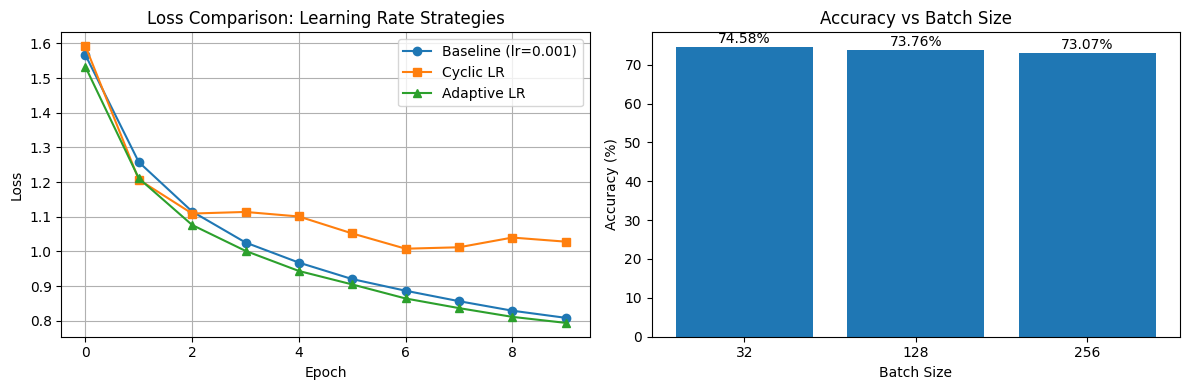

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses_base, label='Baseline (lr=0.001)', marker='o')
plt.plot(losses_clr, label='Cyclic LR', marker='s')
plt.plot(losses_adaptive, label='Adaptive LR', marker='^')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison: Learning Rate Strategies')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
bs_names = [str(bs) for bs in results_batch.keys()]
bs_accs = list(results_batch.values())
plt.bar(bs_names, bs_accs)
plt.xlabel('Batch Size')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Batch Size')
for i, v in enumerate(bs_accs):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()

### 3. Сравнение моделей с разным количеством фильтров и слоев

В данном эксперименте использовалась фиксированная архитектура CNNVariant2 (2 сверточных слоя с 32 и 64 фильтрами). Влияние гиперпараметров оценивалось через изменение стратегий обучения и размера батча.

По стратегиям обучения: Baseline с фиксированным learning rate 0.001 показал точность 73.38% с плавным снижением loss до 0.8085. Adaptive LR (ReduceLROnPlateau) дал лучший результат 74.47%, при этом learning rate не менялся в течение 10 эпох, так как loss стабильно снижался. Cyclic LR показал худший результат 68.34% из-за постоянных колебаний learning rate, которые мешали стабильной сходимости.

По размеру батча: Лучший результат достигнут при batch size 32 с точностью 74.58% и финальным loss 0.7831. При batch size 64 точность составила 73.38%, при 128 - 73.76%, при 256 - 73.07%. Меньший batch size дает более частые обновления весов и лучшее обобщение. Большие batch size ухудшают точность и требуют больше эпох для сходимости.

### 4. Оптимальные настройки гиперпараметров

Лучшая конфигурация на основе экспериментов:

Оптимизатор: Adam

Learning rate: 0.001 (фиксированный или с ReduceLROnPlateau)

Batch size: 32

Количество слоев: 2 сверточных (32 и 64 фильтра)

Эпохи: 10-15

Рекомендации для повышения точности и стабильности:

Использовать batch size 32 как оптимальный баланс между скоростью обучения и обобщающей способностью. Применять Adaptive LR (ReduceLROnPlateau) с patience=3-5 для автоматического снижения learning rate при затухании обучения. Избегать Cyclic LR на малом количестве эпох, так как он требует большего времени для эффективной работы. Для дальнейшего улучшения добавить накопление градиентов при ограниченной памяти, увеличить количество эпох до 20-30, использовать learning rate warmup и комбинировать ReduceLROnPlateau с cosine annealing.

